In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Explaination:
# - tensorflow.keras: High-level neural networks API
# - Sequential: Linear stack of layers
# - Conv2D: 2D convolution layer (feature detection)
# - MaxPooling2D: Reduces spatial size, keeps important features
# - Flatten: Converts 2D to 1D for dense layers
# - Dense: Fully connected layer
# - Dropout: Prevents overfitting by randomly turning off neurons
# - to_categorical: Converts labels to one-hot encoding

2025-11-04 01:50:40.432042: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762221040.716918      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762221040.809892      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("=== DATASET STRUCTURE ===")
print(f"Training data shape: {x_train.shape}")    # (60000, 28, 28)
print(f"Training labels shape: {y_train.shape}")  # (60000,)
print(f"Test data shape: {x_test.shape}")         # (10000, 28, 28) 
print(f"Test labels shape: {y_test.shape}")       # (10000,)
print(f"Image dimensions: {x_train.shape[1]}x{x_train.shape[2]}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Pixel value range: [{x_train.min()}, {x_train.max()}]")

# Metadata
print(f"\n=== CLASS DISTRIBUTION ===")
unique, counts = np.unique(y_train, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} samples")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
=== DATASET STRUCTURE ===
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Image dimensions: 28x28
Number of classes: 10
Pixel value range: [0, 255]

=== CLASS DISTRIBUTION ===
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples


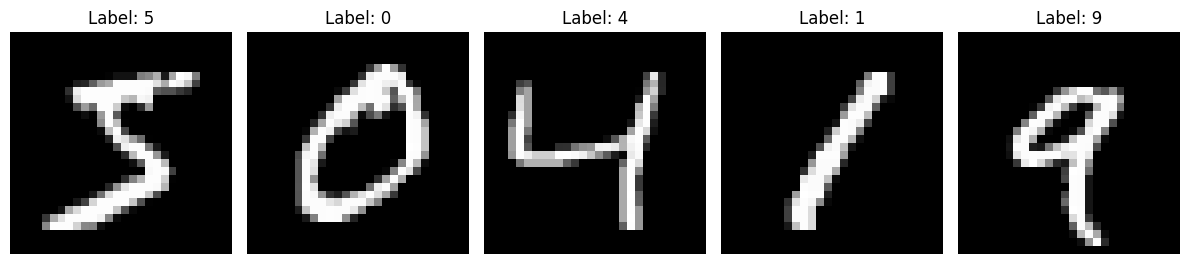


=== PIXEL VALUES (first image, 10x10 corner) ===
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0 

In [4]:
# Display first 5 training images
plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Print actual pixel values for first image (small portion)
print("\n=== PIXEL VALUES (first image, 10x10 corner) ===")
print(x_train[0])  # Show 10x10 top-left corner

In [5]:
# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape data for CNN (add channel dimension)
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)  # (60000, 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)      # (10000, 28, 28, 1)

# Convert labels to one-hot encoding
y_train_categorical = to_categorical(y_train, 10)
y_test_categorical = to_categorical(y_test, 10)

print(f"\n=== AFTER PREPROCESSING ===")
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train_categorical.shape}")
print(f"One-hot example for label {y_train[0]}: {y_train_categorical[0]}")


=== AFTER PREPROCESSING ===
Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000, 10)
One-hot example for label 5: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [6]:
# Simple Pure CNN Model
model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    
    # Second Convolutional Block  
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Classification Block
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Prevents overfitting
    Dense(10, activation='softmax')  # 10 classes for digits 0-9
])

# Model Summary
model.summary()

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-04 01:52:41.814921: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the model
history = model.fit(
    x_train, y_train_categorical,
    batch_size=128,
    epochs=10,
    validation_split=0.2,  # Use 20% of training for validation
    verbose=1
)

# Test the model
test_loss, test_accuracy = model.evaluate(x_test, y_test_categorical, verbose=0)
print(f"\n=== FINAL TEST RESULTS ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.7765 - loss: 0.7067 - val_accuracy: 0.9720 - val_loss: 0.0897
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9649 - loss: 0.1198 - val_accuracy: 0.9861 - val_loss: 0.0509
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9752 - loss: 0.0833 - val_accuracy: 0.9868 - val_loss: 0.0457
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9803 - loss: 0.0627 - val_accuracy: 0.9888 - val_loss: 0.0404
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9840 - loss: 0.0542 - val_accuracy: 0.9887 - val_loss: 0.0388
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.9857 - loss: 0.0473 - val_accuracy: 0.9900 - val_loss: 0.0362
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.9870 - loss: 0.0412 - val_accuracy: 0.9897 - val_loss: 0.0351
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.9898 - loss: 0.0341 - 

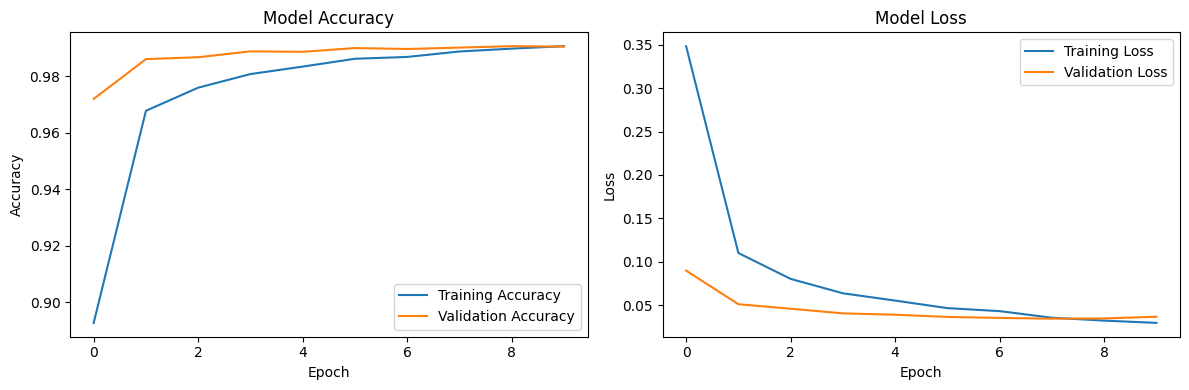


=== OVERFITTING ANALYSIS ===
Final Training Accuracy: 0.9907
Final Validation Accuracy: 0.9905
Accuracy Gap: 0.0002
Small gap (<0.05) indicates good generalization


In [8]:
# Plot training history
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Check for overfitting
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
overfit_gap = final_train_acc - final_val_acc

print(f"\n=== OVERFITTING ANALYSIS ===")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Accuracy Gap: {overfit_gap:.4f}")
print("Small gap (<0.05) indicates good generalization")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       1.00      0.98      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



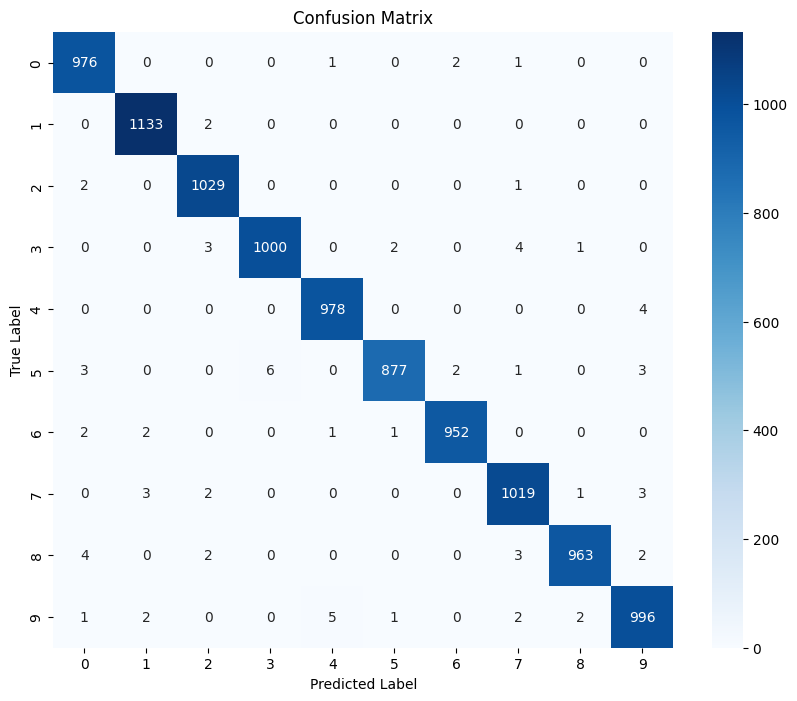


=== PER-CLASS ACCURACY ===
Digit 0: 0.9959
Digit 1: 0.9982
Digit 2: 0.9971
Digit 3: 0.9901
Digit 4: 0.9959
Digit 5: 0.9832
Digit 6: 0.9937
Digit 7: 0.9912
Digit 8: 0.9887
Digit 9: 0.9871


In [9]:
# Predictions for detailed evaluation
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_classes))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Per-class accuracy
class_accuracy = cm.diagonal() / cm.sum(axis=1)
print("\n=== PER-CLASS ACCURACY ===")
for digit, acc in enumerate(class_accuracy):
    print(f"Digit {digit}: {acc:.4f}")